# 01 - Exploratory Data Analysis (EDA)

Dataset: ISOT Fake News Detection (Fake.csv + True.csv)
Task: Binary text classification, fake vs true news

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

## 1. Load Dataset

In [7]:
fake_df = pd.read_csv('../data/raw/Fake.csv')
true_df = pd.read_csv('../data/raw/True.csv')

print('=== FAKE NEWS ===')
print(f'Jumlah artikel: {len(fake_df)}')
print(fake_df.head(3))

print('\n=== TRUE NEWS ===')
print(f'Jumlah artikel: {len(true_df)}')
print(true_df.head(3))

=== FAKE NEWS ===
Jumlah artikel: 23481
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  

=== TRUE NEWS ===
Jumlah artikel: 21417
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat.

Ada 4 kolom: title, text, subject, date. Semua bertipe string. Fake punya 23.481 baris, True punya 21.417 baris. Dari head() sudah kelihatan perbedaan: True selalu diawali pola "KOTA (Reuters) -" di text, sedangkan Fake tidak.

## 2. Cek Kualitas Data

In [8]:
print('=== FAKE INFO ===')
print(fake_df.info())
print(f'\nMemory: {fake_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

print('\n=== TRUE INFO ===')
print(true_df.info())
print(f'\nMemory: {true_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

=== FAKE INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
None

Memory: 65.63 MB

=== TRUE INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB
None

Memory: 81.91 MB


In [9]:
print('Missing values FAKE:')
print(fake_df.isnull().sum())
print('\nMissing values TRUE:')
print(true_df.isnull().sum())

Missing values FAKE:
title      0
text       0
subject    0
date       0
dtype: int64

Missing values TRUE:
title      0
text       0
subject    0
date       0
dtype: int64


In [10]:
print(f'Fake duplikat: {fake_df.duplicated().sum()} ({fake_df.duplicated().sum()/len(fake_df)*100:.2f}%)')
print(f'True duplikat: {true_df.duplicated().sum()} ({true_df.duplicated().sum()/len(true_df)*100:.2f}%)')
print(f'\nFake teks kosong: {(fake_df["text"].isna() | (fake_df["text"].str.strip() == "")).sum()}')
print(f'True teks kosong: {(true_df["text"].isna() | (true_df["text"].str.strip() == "")).sum()}')

Fake duplikat: 3 (0.01%)
True duplikat: 206 (0.96%)

Fake teks kosong: 630
True teks kosong: 1


Tidak ada missing values di kedua dataset. Untuk duplikat, Fake cuma 3 baris (0.01%), tapi True cukup banyak yaitu 206 baris (0.96%). Duplikat ini harus dihapus agar model tidak belajar dari data yang sama dua kali.

Yang menarik adalah teks kosong: 630 artikel Fake isinya kosong, cuma berisi judul saja. Ini kemungkinan artikel clickbait yang memang tidak punya konten, atau error saat scraping. Satu artikel True juga kosong. Semua ini perlu ditangani di preprocessing.

## 3. Gabungkan Dataset & Buat Label

In [11]:
fake_df['label'] = 0
true_df['label'] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.drop_duplicates().reset_index(drop=True)

print(f'Total artikel setelah gabung dan hapus duplikat: {len(df)}')
print(f'\nDistribusi label:')
print(df['label'].value_counts())
print(f'\nPersentase:')

Total artikel setelah gabung dan hapus duplikat: 44689

Distribusi label:
label
0    23478
1    21211
Name: count, dtype: int64

Persentase:


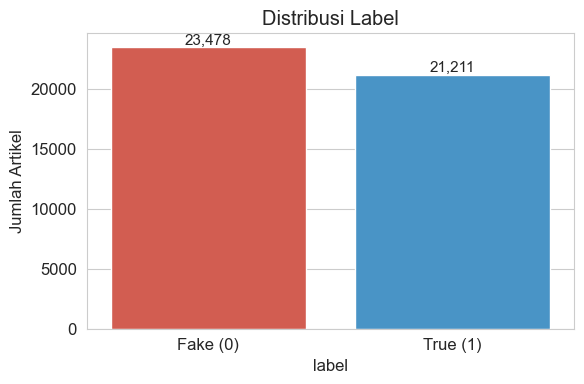

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#e74c3c', '#3498db']
ax = sns.countplot(x='label', data=df, palette=colors)
ax.set_xticklabels(['Fake (0)', 'True (1)'])
plt.title('Distribusi Label')
plt.ylabel('Jumlah Artikel')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('../images/01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Total jadi 44.689 artikel setelah duplikat dihapus. Distribusinya cukup seimbang, Fake 52.54% dan True 47.46%. Selisihnya cuma sekitar 5%, jadi tidak perlu pakai teknik seperti SMOTE. Model bisa dilatih langsung tanpa khawatir bias ke satu kelas.

## 4. Cek Data Leakage: Kolom `subject`

In [13]:
print('Subject di FAKE:')
print(fake_df['subject'].value_counts())
print('\nSubject di TRUE:')
print(true_df['subject'].value_counts())

fake_subjects = set(fake_df['subject'].unique())
true_subjects = set(true_df['subject'].unique())
overlap = fake_subjects.intersection(true_subjects)
print(f'\nKategori Fake: {fake_subjects}')
print(f'Kategori True: {true_subjects}')
print(f'Overlap: {overlap if overlap else "TIDAK ADA"}')

Subject di FAKE:
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

Subject di TRUE:
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64

Kategori Fake: {'News', 'Middle-east', 'Government News', 'left-news', 'politics', 'US_News'}
Kategori True: {'politicsNews', 'worldnews'}
Overlap: TIDAK ADA


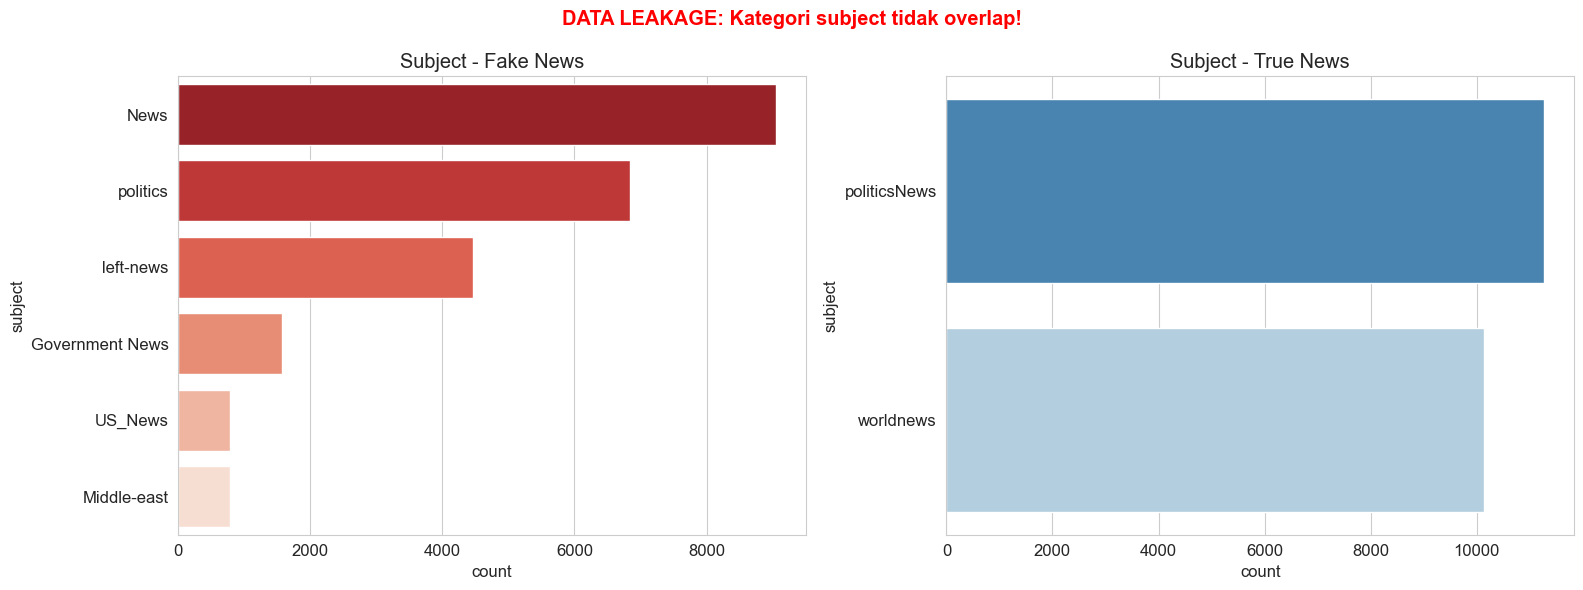

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(y='subject', data=fake_df, ax=axes[0], palette='Reds_r',
              order=fake_df['subject'].value_counts().index)
axes[0].set_title('Subject - Fake News')
sns.countplot(y='subject', data=true_df, ax=axes[1], palette='Blues_r',
              order=true_df['subject'].value_counts().index)
axes[1].set_title('Subject - True News')
plt.suptitle('DATA LEAKAGE: Kategori subject tidak overlap!', color='red', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/02_subject_leakage.png', dpi=150, bbox_inches='tight')
plt.show()

Ini masalah besar. Kategori subject di Fake dan True sama sekali tidak ada yang sama. Fake punya 6 kategori (News, politics, left-news, Government News, US_News, Middle-east), True cuma 2 (politicsNews, worldnews).

Kalau kolom ini dipakai sebagai fitur, model akan curang. Cukup pelajari: kalau subject "News" maka Fake, kalau "worldnews" maka True. Akurasi bisa tinggi tapi model tidak belajar sama sekali membedakan isi berita. Kolom subject harus dihapus di preprocessing.

## 5. Analisis Panjang Teks

In [15]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))

print('Statistik panjang teks (jumlah kata):')
df.groupby('label')[['text_length', 'title_length']].describe().round(1)

Statistik panjang teks (jumlah kata):


text_length                                                  \
            count   mean    std  min    25%    50%    75%     max   
label                                                               
0         23478.0  423.2  408.4  0.0  240.0  363.0  506.0  8135.0   
1         21211.0  384.8  273.9  0.0  147.0  359.0  523.0  5172.0   

      title_length                                          
             count  mean  std  min   25%   50%   75%   max  
label                                                       
0          23478.0  14.7  4.3  1.0  12.0  14.0  17.0  42.0  
1          21211.0  10.0  1.7  4.0   9.0  10.0  11.0  20.0

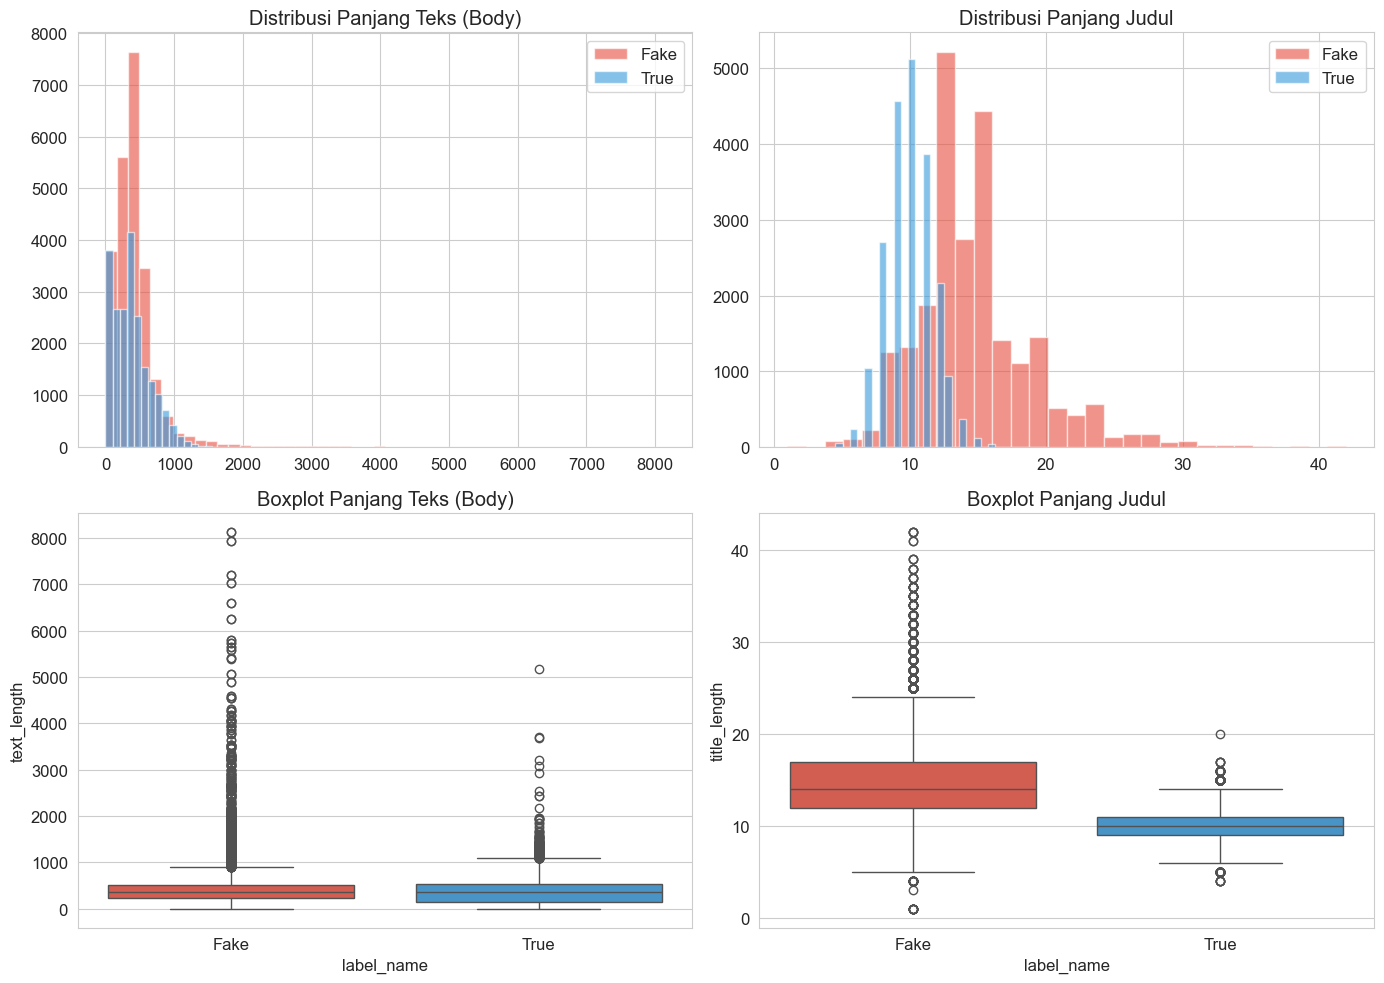

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for label, color, name in [(0, '#e74c3c', 'Fake'), (1, '#3498db', 'True')]:
    subset = df[df['label'] == label]
    axes[0, 0].hist(subset['text_length'], bins=50, alpha=0.6, color=color, label=name)
    axes[0, 1].hist(subset['title_length'], bins=30, alpha=0.6, color=color, label=name)
axes[0, 0].set_title('Distribusi Panjang Teks (Body)')
axes[0, 0].legend()
axes[0, 1].set_title('Distribusi Panjang Judul')
axes[0, 1].legend()

df['label_name'] = df['label'].map({0: 'Fake', 1: 'True'})
sns.boxplot(x='label_name', y='text_length', data=df, ax=axes[1, 0], palette=colors)
axes[1, 0].set_title('Boxplot Panjang Teks (Body)')
sns.boxplot(x='label_name', y='title_length', data=df, ax=axes[1, 1], palette=colors)
axes[1, 1].set_title('Boxplot Panjang Judul')
plt.tight_layout()
plt.savefig('../images/03_text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Beberapa temuan dari statistik panjang teks:

Body text: Fake rata-rata 423 kata, True rata-rata 385 kata. Fake lebih panjang. Standar deviasi Fake juga lebih besar (408 vs 274), artinya variasi panjang teks Fake lebih tinggi, ada yang sangat panjang sampai 8.135 kata.

Judul: Fake rata-rata 14.7 kata, True cuma 10 kata. Judul Fake lebih panjang karena gaya clickbait. Standar deviasi True sangat kecil (1.7), menunjukkan pola penulisan judul Reuters sangat seragam.

Min 0 kata di body text untuk kedua kelas itu terkait dengan 630 teks kosong yang sudah ditemukan tadi.

## 6. Cek Data Leakage: Pola Reuters

In [17]:
patterns = {
    '(Reuters)': r'\(Reuters\)',
    'WASHINGTON (Reuters)': r'WASHINGTON\s*\(Reuters\)',
    'NEW YORK (Reuters)': r'NEW YORK\s*\(Reuters\)',
    '(AP)': r'\(AP\)',
    '(AFP)': r'\(AFP\)',
}

print('Pola sumber berita di data:')
for name, pattern in patterns.items():
    mask = df['text'].str.contains(pattern, case=False, na=False)
    t = (mask & (df['label']==1)).sum()
    f = (mask & (df['label']==0)).sum()
    print(f'{name:25s}: {mask.sum():5d} total ({t} true, {f} fake)')

Pola sumber berita di data:
(Reuters)                : 21050 total (21041 true, 9 fake)
WASHINGTON (Reuters)     :  6642 total (6639 true, 3 fake)
NEW YORK (Reuters)       :   841 total (841 true, 0 fake)
(AP)                     :    33 total (1 true, 32 fake)
(AFP)                    :     9 total (1 true, 8 fake)


In [18]:
reuters_mask = df['text'].str.contains(r'\(Reuters\)', case=False, na=False)
sample = df[(df['label']==1) & reuters_mask]['text'].iloc[0]
print('Contoh artikel True dengan pola Reuters:')
print(sample[:400])

Contoh artikel True dengan pola Reuters:
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard


Dari 21.050 artikel yang mengandung pola "(Reuters)", 21.041 di antaranya True. Artinya 99.96% artikel dengan pola ini adalah berita asli. Pola "WASHINGTON (Reuters)" saja muncul di 6.639 artikel True.

Kalau pola ini tidak dihapus, model akan belajar bahwa kata "Reuters" atau "WASHINGTON" itu indikator berita asli. Itu bukan pemahaman terhadap konten berita, tapi cuma mengenali format penulisan kantor berita. Pola sumber berita juga harus dibersihkan di preprocessing.

## 7. Sample Data

Melihat sample data penting untuk memahami karakteristik teks yang tidak terlihat dari angka saja, seperti gaya bahasa, format penulisan, dan nada yang digunakan.

In [19]:
print('=== SAMPLE FAKE NEWS ===')
for i, row in fake_df.sample(3, random_state=42).iterrows():
    print(f'\nTitle: {row["title"]}')
    print(f'Subject: {row["subject"]}')
    print(f'Text: {row["text"][:200]}...')
    print('-' * 40)

=== SAMPLE FAKE NEWS ===

Title: ABOUT HILLARY’S COUGH: We Discovered The Secret To Why She Keeps Coughing [Video]
Subject: politics
Text:  ...
----------------------------------------

Title: BREAKING: OBAMACARE REPEAL Clears First Hurdle…Dems Get Snarky
Subject: politics
Text: The Senate voted 51-48 this afternoon to proceed to the resolution, S. Con. Res. 3, which would set up a filibuster-proof process, ensuring the chamber s consideration of legislation repealing parts o...
----------------------------------------

Title: ‘SLEEPY’ JUSTICE GINSBURG: Excites Crowd By Saying She’d Back Abolition Of The Electoral College [Video]
Subject: left-news
Text: So much for the SCOTUS not being political Check out her comments on equality for women. It s like she s time traveled back to the 50 s. What is the deal with these women that think we re still in the...
----------------------------------------


Dari sample fake news bisa dilihat beberapa pola:

Judulnya cenderung clickbait, pakai huruf kapital berlebihan, tanda baca emosional. Contoh: "ABOUT HILLARY'S COUGH: We Discovered The Secret To Why She Keeps Coughing [Video]". Gaya bahasanya subjektif dan opinionated, bukan faktual. Ada yang text-nya kosong sama sekali, hanya berisi judul. Beberapa pakai tanda seru dan bahasa yang memancing emosi.

In [20]:
print('=== SAMPLE TRUE NEWS ===')
for i, row in true_df.sample(3, random_state=42).iterrows():
    print(f'\nTitle: {row["title"]}')
    print(f'Subject: {row["subject"]}')
    print(f'Text: {row["text"][:200]}...')
    print('-' * 40)

=== SAMPLE TRUE NEWS ===

Title: Europe rights watchdog says Turkey's emergency laws go too far
Subject: worldnews
Text: BRUSSELS (Reuters) - A leading European rights watchdog called on Turkey on Friday to ease post-coup state of emergency laws that have seen thousands arrested and restore power to regional authorities...
----------------------------------------

Title: Exclusive: Trump targets illegal immigrants who were given reprieves from deportation by Obama
Subject: politicsNews
Text: (Reuters) - In September 2014, Gilberto Velasquez, a 38-year-old house painter from El Salvador, received life-changing news: The U.S. government had decided to shelve its deportation action against h...
----------------------------------------

Title: At G20 summit, Trump pledges $639 million in aid to four countries
Subject: politicsNews
Text: HAMBURG (Reuters) - U.S. President Donald Trump on Saturday promised $639 million in aid to feed people left starving because of drought and conflict in So

True news sangat berbeda. Judulnya pendek, faktual, langsung pada intinya tanpa clickbait. Selalu diawali pola lokasi dan sumber, misalnya "BRUSSELS (Reuters) -" atau "HAMBURG (Reuters) -". Nada penulisannya netral dan objektif. Body text lengkap, terstruktur, berisi fakta, nama pejabat, angka, dan kutipan langsung.

## 8. Frekuensi Kata per Kelas

In [21]:
import re

stopwords = set([
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'by', 'from', 'is', 'was', 'are', 'were', 'been', 'be',
    'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
    'should', 'may', 'might', 'shall', 'can', 'it', 'its', 'he', 'she',
    'they', 'them', 'their', 'this', 'that', 'these', 'those', 'not', 'no',
    'if', 'so', 'than', 'too', 'very', 'just', 'about', 'into',
    'over', 'after', 'before', 'between', 'under', 'again', 'then', 'once',
    'here', 'there', 'when', 'where', 'why', 'how', 'all', 'each', 'every',
    'both', 'few', 'more', 'most', 'other', 'some', 'such', 'only', 'own',
    'same', 'as', 'also', 'what', 'which', 'who', 'whom', 'up', 'out',
    'said', 'new', 'one', 'two', 'first', 'last', 'like', 'even', 'many',
    'much', 'well', 'back', 'good', 'get', 'make', 'us', 're', 's'
])

def get_top_words(texts, n=20):
    words = []
    for text in texts.dropna():
        tokens = re.sub(r'[^a-zA-Z\s]', '', text.lower()).split()
        words.extend([w for w in tokens if w not in stopwords and len(w) > 2])
    return Counter(words).most_common(n)

top_fake = get_top_words(df[df['label']==0]['text'])
top_true = get_top_words(df[df['label']==1]['text'])

print('Top 20 kata - FAKE NEWS:')
for word, count in top_fake:
    print(f'  {word:20s}: {count:,}')

print('\nTop 20 kata - TRUE NEWS:')
for word, count in top_true:
    print(f'  {word:20s}: {count:,}')

Top 20 kata - FAKE NEWS:
  trump               : 73,933
  his                 : 58,032
  you                 : 39,954
  people              : 25,963
  her                 : 25,634
  president           : 25,585
  our                 : 19,719
  clinton             : 18,006
  obama               : 17,813
  donald              : 17,215
  him                 : 16,634
  because             : 15,483
  news                : 14,126
  hillary             : 13,560
  now                 : 13,238
  white               : 12,774
  time                : 12,727
  state               : 12,525
  being               : 12,083
  any                 : 11,465

Top 20 kata - TRUE NEWS:
  trump               : 42,117
  his                 : 37,562
  reuters             : 28,110
  president           : 25,272
  state               : 18,557
  government          : 17,708
  states              : 17,408
  house               : 16,259
  united              : 15,351
  republican          : 15,207
  people           

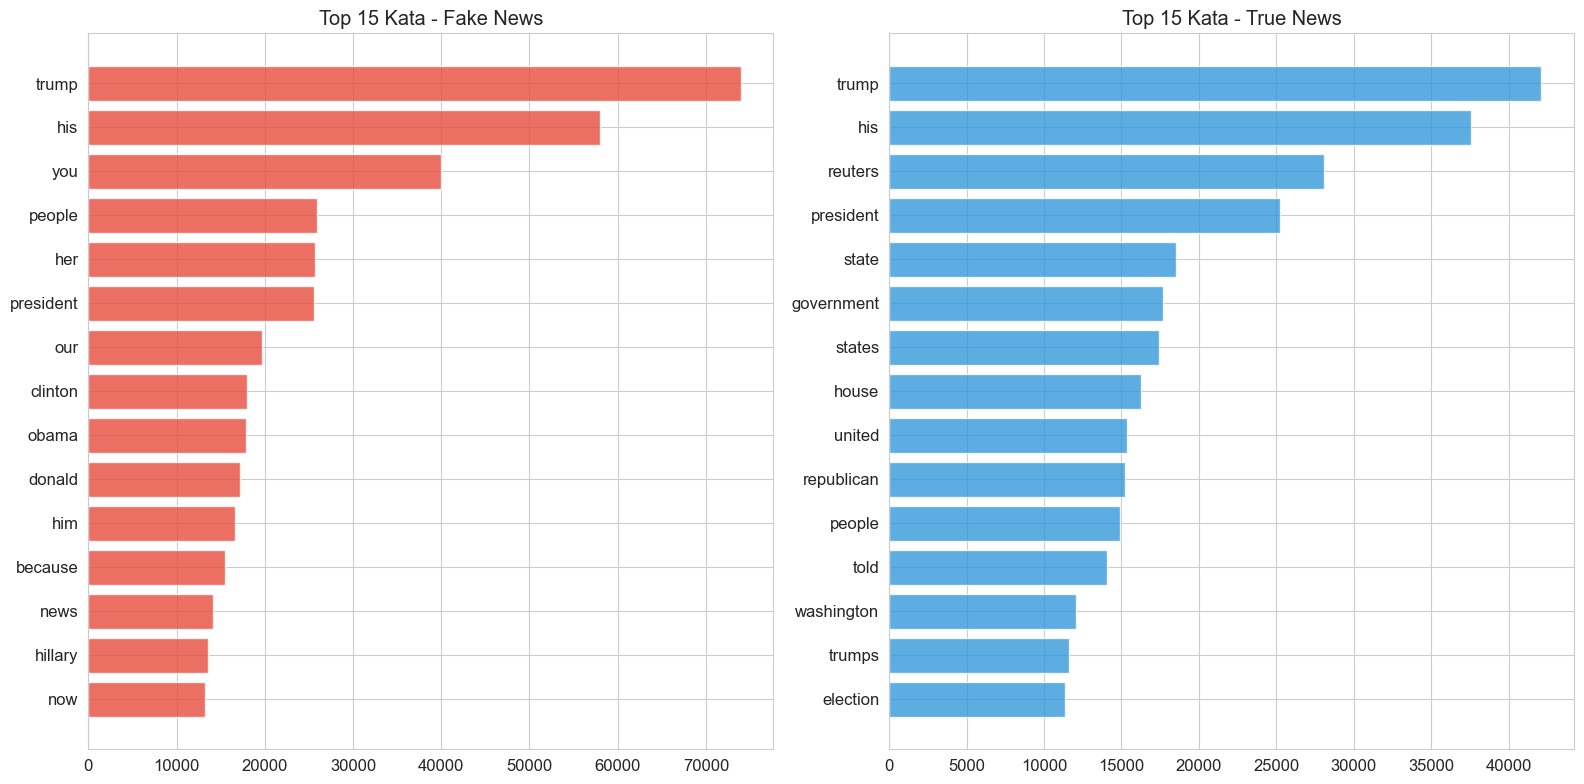

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fake_words, fake_counts = zip(*top_fake[:15])
true_words, true_counts = zip(*top_true[:15])

axes[0].barh(range(15), fake_counts, color='#e74c3c', alpha=0.8)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(fake_words)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Kata - Fake News')

axes[1].barh(range(15), true_counts, color='#3498db', alpha=0.8)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(true_words)
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Kata - True News')

plt.tight_layout()
plt.savefig('../images/04_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

Perbedaan pola kata antara kelas cukup jelas:

Fake news: kata-kata yang dominan bersifat personal dan emosional seperti "you", "his", "her", "people", "because". Fokus pada politisi tertentu: "clinton" (18.006), "obama" (17.813), "hillary" (13.560). Gaya bahasanya lebih ke opini.

True news: kata-kata yang dominan bersifat institusional dan faktual seperti "government", "states", "house", "republican". Muncul juga kata sumber berita: "reuters" (28.110), "washington" (12.052). Gaya bahasanya lebih ke pelaporan.

Kata "trump" muncul di kedua kelas tapi frekuensinya sangat berbeda, 73.933 di Fake vs 42.117 di True. Kata "reuters" hanya dominan di True, ini potensi data leakage yang harus diwaspadai.

## 9. Simpan Data

In [23]:
df.to_csv('../data/processed/raw_combined.csv', index=False)
print(f'Data gabungan tersimpan: {len(df)} baris')

Data gabungan tersimpan: 44689 baris


## Langkah Selanjutnya

Dari EDA ini ada beberapa hal yang harus ditangani di preprocessing:

1. Hapus kolom subject karena kategorinya tidak overlap antara fake dan true, ini data leakage.
2. Bersihkan pola Reuters dan sumber berita lain dari teks, karena 99.96% artikel dengan pola "(Reuters)" adalah true news.
3. Tangani 630 teks kosong di kelas fake, bisa dihapus atau diimputasi dari judul.
4. Hapus 209 duplikat yang sudah ditemukan.
5. Lakukan lowercase, hapus tanda baca, angka, dan links.
6. Gabungkan kolom title dan text jadi satu kolom penuh.